# Randell Smith

# RS Notebook: Modeling & Evaluation

Goal: Predict county-level corn yield using emissions subsectors.

Core decisions to prevent leakage:
- Split by **year** (train=2021, val=2022, test=2023)
- Fit preprocessing (StandardScaler) on **train only**
- Drop non-causal / ID columns (County, State) from model inputs
- Evaluate with RMSE + MAE + R² and compare to a baseline

In [19]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
DATA_PATH = "../data/clean_data.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", list(df.columns))

# Column Contract
COL_YEAR = "Year"
COL_TARGET = "Corn Yield"

ID_COLS = ["State", "County"]  # drop from X to avoid model memorization of state/country

FEATURE_COLS = [
    "Crop Fire Emissions",
    "Crop Residue Emissions",
    "Manure Fertilizer Emissions",
    "Soil Emissions",
    "Synthetic Fertilizer Emissions"
]

# Sanity checks
missing = [c for c in [COL_YEAR, COL_TARGET] + ID_COLS + FEATURE_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

df[[COL_YEAR, COL_TARGET] + ID_COLS + FEATURE_COLS].head()

Shape: (4311, 9)
Columns: ['Year', 'State', 'County', 'Crop Fire Emissions', 'Crop Residue Emissions', 'Manure Fertilizer Emissions', 'Soil Emissions', 'Synthetic Fertilizer Emissions', 'Corn Yield']


,Year,Corn Yield,State,County,Crop Fire Emissions,Crop Residue Emissions,Manure Fertilizer Emissions,Soil Emissions,Synthetic Fertilizer Emissions
0,2021,151.282051,ALABAMA,BALDWIN,8564.807217,4668.08706,10456.16208,59019.547184,45922.77690
1,2021,183.478261,ALABAMA,BARBOUR,589.283512,1090.00710,4432.23144,33297.901576,28706.69802
2,2021,147.142857,ALABAMA,BLOUNT,296.569885,4114.03356,5180.99400,24484.589499,29192.38686
3,2021,157.000000,ALABAMA,CALHOUN,0.022775,698.57970,1804.48632,21651.332000,11389.65828
4,2021,168.250000,ALABAMA,CHEROKEE,0.000035,1162.95270,2349.95124,22010.477311,16576.77840


**Sanity Checking**: Verify year coverage (should be 2021–2023).

Check missingness in features/target (should be minimal if cleaned).

Check target distribution quickly.

Year counts:
 Year
2021    1442
2022    1473
2023    1396
Name: count, dtype: int64

Missingness (features):
Crop Fire Emissions               0.0
Crop Residue Emissions            0.0
Manure Fertilizer Emissions       0.0
Soil Emissions                    0.0
Synthetic Fertilizer Emissions    0.0
dtype: float64

Missingness (target): 0.0

Target summary:
count    4311.000000
mean      142.470163
std        46.239872
min         0.000000
25%       111.071450
50%       148.265896
75%       179.515712
max       236.415313
Name: Corn Yield, dtype: float64


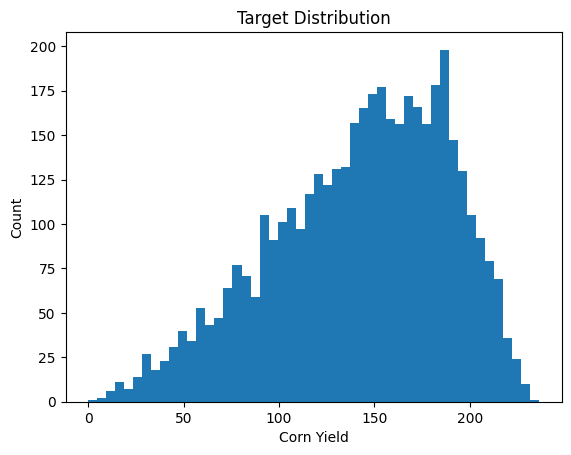

In [21]:
print("Year counts:\n", df[COL_YEAR].value_counts().sort_index())

print("\nMissingness (features):")
print(df[FEATURE_COLS].isna().mean().sort_values(ascending=False))

print("\nMissingness (target):", df[COL_TARGET].isna().mean())

print("\nTarget summary:")
print(df[COL_TARGET].describe())

plt.figure()
plt.hist(df[COL_TARGET].values, bins=50)
plt.xlabel("Corn Yield")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.show()

We split by year to avoid “cluster leakage” where counties repeat across splits.

This simulates real forecasting: train on earlier years → predict later years.

In [22]:
TRAIN_YEAR, VAL_YEAR, TEST_YEAR = 2021, 2022, 2023

train_df = df[df[COL_YEAR] == TRAIN_YEAR].copy()
val_df   = df[df[COL_YEAR] == VAL_YEAR].copy()
test_df  = df[df[COL_YEAR] == TEST_YEAR].copy()

print("Train/Val/Test shapes:", train_df.shape, val_df.shape, test_df.shape)

train_counties = set(zip(train_df["State"], train_df["County"]))
val_counties   = set(zip(val_df["State"], val_df["County"]))
test_counties  = set(zip(test_df["State"], test_df["County"]))

print("County overlap Train∩Val:", len(train_counties & val_counties))
print("County overlap Train∩Test:", len(train_counties & test_counties))
print("County overlap Val∩Test:", len(val_counties & test_counties))

Train/Val/Test shapes: (1442, 9) (1473, 9) (1396, 9)
County overlap Train∩Val: 1239
County overlap Train∩Test: 1180
County overlap Val∩Test: 1222


X should contain only emissions features (causal-ish predictors).

Drop target to avoid target leakage.

Drop identifiers to avoid memorization.

In [23]:
def make_xy(split_df: pd.DataFrame):
    # Decision: model sees only emissions predictors
    X = split_df[FEATURE_COLS].copy()
    y = split_df[COL_TARGET].copy()
    return X, y

X_train_raw, y_train = make_xy(train_df)
X_val_raw, y_val     = make_xy(val_df)
X_test_raw, y_test   = make_xy(test_df)

print("X_train:", X_train_raw.shape, "y_train:", y_train.shape)

X_train: (1442, 5) y_train: (1442,)


Neural nets generally train better with standardized inputs.

Fit scaler on train only to prevent peeking at val/test distribution.

Transform val/test using train-fitted scaler.

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

# Quick check: train should be ~mean 0, std 1 (per feature)
print("Train mean (approx):", np.round(X_train.mean(axis=0), 3))
print("Train std (approx):", np.round(X_train.std(axis=0), 3))

Train mean (approx): [ 0. -0. -0.  0. -0.]
Train std (approx): [1. 1. 1. 1. 1.]


Use one evaluation function so all models are compared fairly.

Track RMSE, MAE, R² (common regression metrics).

In [25]:
def regression_metrics(y_true, y_pred, label=""):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {"model": label, "rmse": rmse, "mae": mae, "r2": r2} 

Baseline establishes “minimum acceptable performance.”

Mean predictor is the simplest honest regression baseline.

In [26]:
baseline_mean = float(y_train.mean())

val_pred_baseline = np.full(shape=len(y_val), fill_value=baseline_mean)
test_pred_baseline = np.full(shape=len(y_test), fill_value=baseline_mean)

results = []
results.append(regression_metrics(y_val, val_pred_baseline, "Baseline: Train Mean (Val)"))
results.append(regression_metrics(y_test, test_pred_baseline, "Baseline: Train Mean (Test)"))

pd.DataFrame(results)

,model,rmse,mae,r2
0,Baseline: Train Mean (Val),50.684309,40.92954,-0.041244
1,Baseline: Train Mean (Test),43.624291,36.42323,-0.002134


This is your first improvement: a learned linear mapping from 5 inputs → yield.

Use MSE loss, Adam optimizer.

Early stopping to prevent overfitting.

In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

model_lin = Sequential([
    Dense(1, input_shape=(X_train.shape[1],), activation="linear")
])

model_lin.compile(optimizer="adam", loss="mse")

hist_lin = model_lin.fit(
    X_train, y_train.values,
    validation_data=(X_val, y_val.values),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

# Evaluate
val_pred_lin = model_lin.predict(X_val).ravel()
test_pred_lin = model_lin.predict(X_test).ravel()

results = []
results.append(regression_metrics(y_val, val_pred_lin, "Linear NN (Val)"))
results.append(regression_metrics(y_test, test_pred_lin, "Linear NN (Test)"))

pd.DataFrame(results)

44/44 [==============================] - 0s 677us/step


,model,rmse,mae,r2
0,Linear NN (Val),134.525234,126.166796,-6.335215
1,Linear NN (Test),143.325105,137.414063,-9.817172


Plot train vs val loss to demonstrate generalization / overfitting control.

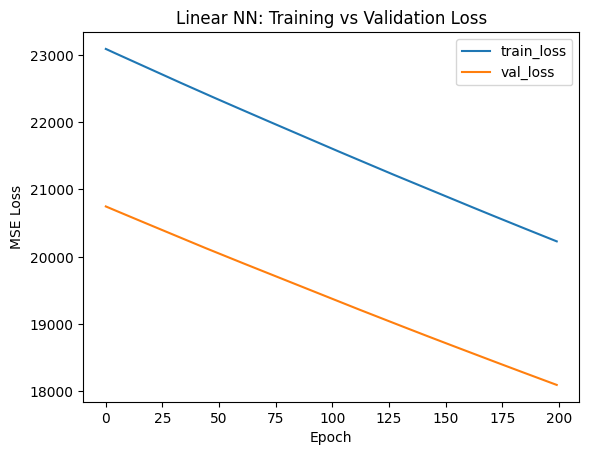

In [28]:
plt.figure()
plt.plot(hist_lin.history["loss"], label="train_loss")
plt.plot(hist_lin.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Linear NN: Training vs Validation Loss")
plt.legend()
plt.show()

A modest hidden layer gives nonlinearity.

Keep model small because you have limited years (and repeated counties).

Use early stopping again.

In [29]:
from tensorflow.keras.layers import Dropout

model_deep = Sequential([
    Dense(12, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(1, activation="linear")
])

model_deep.compile(optimizer="adam", loss="mse")

hist_deep = model_deep.fit(
    X_train, y_train.values,
    validation_data=(X_val, y_val.values),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

val_pred_deep = model_deep.predict(X_val).ravel()
test_pred_deep = model_deep.predict(X_test).ravel()

results = []
results.append(regression_metrics(y_val, val_pred_deep, "Deep NN (Val)"))
results.append(regression_metrics(y_test, test_pred_deep, "Deep NN (Test)"))

pd.DataFrame(results)

44/44 [==============================] - 0s 1ms/step


,model,rmse,mae,r2
0,Deep NN (Val),37.375316,28.913529,0.433793
1,Deep NN (Test),33.224354,25.332338,0.418724


One table = easy for milestone.

Include baseline + both NNs for val + test.

In [30]:
rows = []

# baseline
rows.append(regression_metrics(y_val, val_pred_baseline, "Baseline Mean (Val)"))
rows.append(regression_metrics(y_test, test_pred_baseline, "Baseline Mean (Test)"))

# linear nn
rows.append(regression_metrics(y_val, val_pred_lin, "Linear NN (Val)"))
rows.append(regression_metrics(y_test, test_pred_lin, "Linear NN (Test)"))

# deep nn
rows.append(regression_metrics(y_val, val_pred_deep, "Deep NN (Val)"))
rows.append(regression_metrics(y_test, test_pred_deep, "Deep NN (Test)"))

results_df = pd.DataFrame(rows)
results_df

,model,rmse,mae,r2
0,Baseline Mean (Val),50.684309,40.929540,-0.041244
1,Baseline Mean (Test),43.624291,36.423230,-0.002134
2,Linear NN (Val),134.525234,126.166796,-6.335215
3,Linear NN (Test),143.325105,137.414063,-9.817172
4,Deep NN (Val),37.375316,28.913529,0.433793
5,Deep NN (Test),33.224354,25.332338,0.418724


Visual sanity check: points should cluster around y=x line.

Use test set to show generalization.

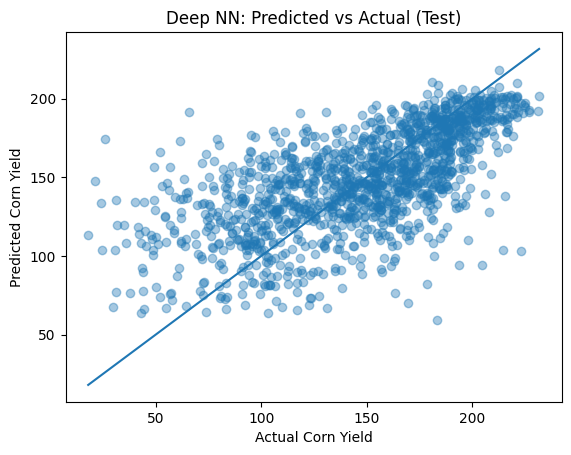

In [31]:
plt.figure()
plt.scatter(y_test, test_pred_deep, alpha=0.4)
minv = min(y_test.min(), test_pred_deep.min())
maxv = max(y_test.max(), test_pred_deep.max())
plt.plot([minv, maxv], [minv, maxv])
plt.xlabel("Actual Corn Yield")
plt.ylabel("Predicted Corn Yield")
plt.title("Deep NN: Predicted vs Actual (Test)")
plt.show()

Residuals should be centered around 0.

Patterns indicate systematic bias or missing features.

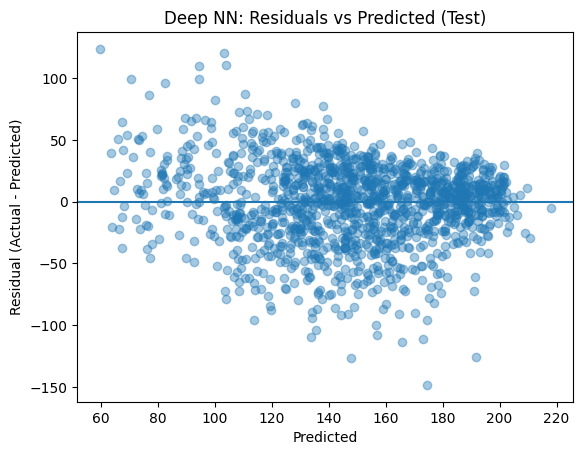

In [32]:
residuals = y_test.values - test_pred_deep

plt.figure()
plt.scatter(test_pred_deep, residuals, alpha=0.4)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Deep NN: Residuals vs Predicted (Test)")
plt.show()


Epoch 50: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 58: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 72: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 80: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 88: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Restoring model weights from the end of the best epoch: 64.
Epoch 89: early stopping


,model,rmse,mae,r2
0,Final Tuned NN (Val),36.090304,28.728163,0.472058
1,Final Tuned NN (Test),32.552570,25.594985,0.441993


,model,rmse,mae,r2
0,Baseline Mean (Val),50.684309,40.929540,-0.041244
1,Baseline Mean (Test),43.624291,36.423230,-0.002134
2,Linear NN (Val),134.525234,126.166796,-6.335215
3,Linear NN (Test),143.325105,137.414063,-9.817172
4,Deep NN (Val),37.375316,28.913529,0.433793
5,Deep NN (Test),33.224354,25.332338,0.418724
6,Final Tuned NN (Val),36.090304,28.728163,0.472058
7,Final Tuned NN (Test),32.552570,25.594985,0.441993


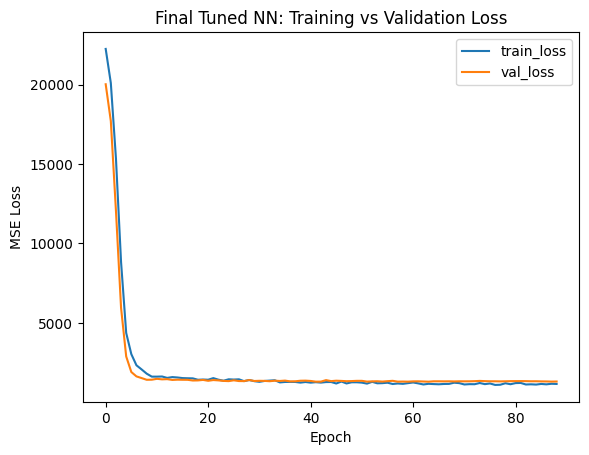

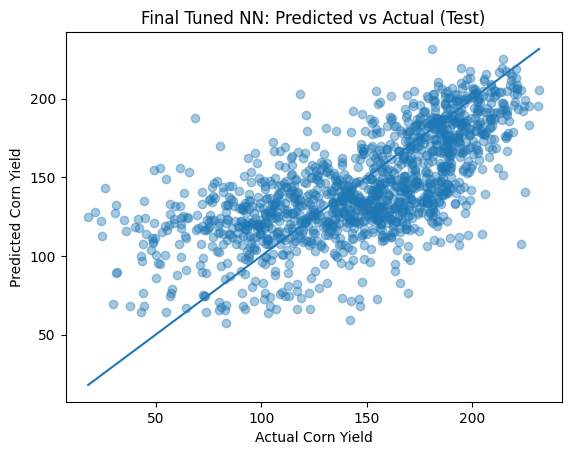

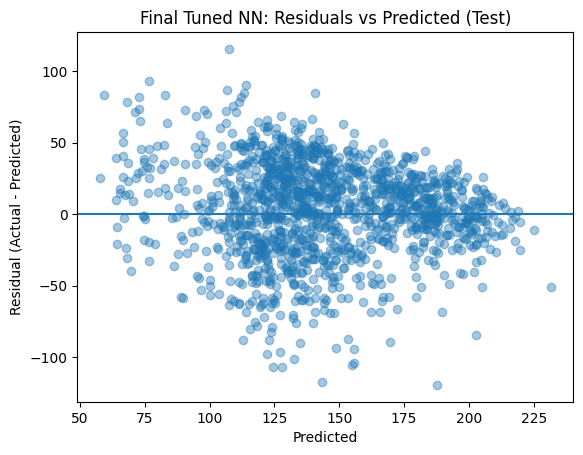

In [33]:
# Final tuned model: dropout + batch normalization + L2 regularization +
# adaptive learning rate + early stopping
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Reproducibility
tf.keras.backend.clear_session()
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

early_stop_final = EarlyStopping(
    monitor="val_loss",
    patience=25,
    min_delta=1e-3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=8,
    min_lr=1e-5,
    verbose=1
)

model_final = Sequential([
    Input(shape=(X_train.shape[1],)),
    
    Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-3)
    ),
    BatchNormalization(),
    Dropout(0.30),

    Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-3)
    ),
    BatchNormalization(),
    Dropout(0.20),

    Dense(
        16,
        activation="relu",
        kernel_regularizer=regularizers.l2(5e-4)
    ),
    Dense(1, activation="linear")
])

model_final.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

hist_final = model_final.fit(
    X_train,
    y_train.values,
    validation_data=(X_val, y_val.values),
    epochs=500,
    batch_size=16,
    callbacks=[early_stop_final, reduce_lr],
    verbose=0
)

# Predictions
val_pred_final = model_final.predict(X_val, verbose=0).ravel()
test_pred_final = model_final.predict(X_test, verbose=0).ravel()

# Metrics
final_rows = [
    regression_metrics(y_val, val_pred_final, "Final Tuned NN (Val)"),
    regression_metrics(y_test, test_pred_final, "Final Tuned NN (Test)")
]

final_results_df = pd.DataFrame(final_rows)
display(final_results_df)

# Append to overall comparison table if results_df already exists
try:
    results_df = pd.concat([results_df, final_results_df], ignore_index=True)
    display(results_df)
except NameError:
    pass

# Learning curves
plt.figure()
plt.plot(hist_final.history["loss"], label="train_loss")
plt.plot(hist_final.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Final Tuned NN: Training vs Validation Loss")
plt.legend()
plt.show()

# Predicted vs actual on test
plt.figure()
plt.scatter(y_test, test_pred_final, alpha=0.4)
minv = min(y_test.min(), test_pred_final.min())
maxv = max(y_test.max(), test_pred_final.max())
plt.plot([minv, maxv], [minv, maxv])
plt.xlabel("Actual Corn Yield")
plt.ylabel("Predicted Corn Yield")
plt.title("Final Tuned NN: Predicted vs Actual (Test)")
plt.show()

# Residual plot on test
final_residuals = y_test.values - test_pred_final
plt.figure()
plt.scatter(test_pred_final, final_residuals, alpha=0.4)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Final Tuned NN: Residuals vs Predicted (Test)")
plt.show()

,model,rmse,mae,r2
0,XGBoost (Val),35.407438,26.827717,0.491847
1,XGBoost (Test),30.648528,23.429321,0.505361


,model,rmse,mae,r2
0,XGBoost (Test),30.648528,23.429321,0.505361
1,XGBoost (Test),30.648528,23.429321,0.505361
2,XGBoost (Val),35.407438,26.827717,0.491847
3,XGBoost (Val),35.407438,26.827717,0.491847
4,Final Tuned NN (Val),36.090304,28.728163,0.472058
5,Final Tuned NN (Test),32.552570,25.594985,0.441993
6,Deep NN (Val),37.375316,28.913529,0.433793
7,Deep NN (Test),33.224354,25.332338,0.418724
8,Baseline Mean (Test),43.624291,36.423230,-0.002134
9,Baseline Mean (Val),50.684309,40.929540,-0.041244


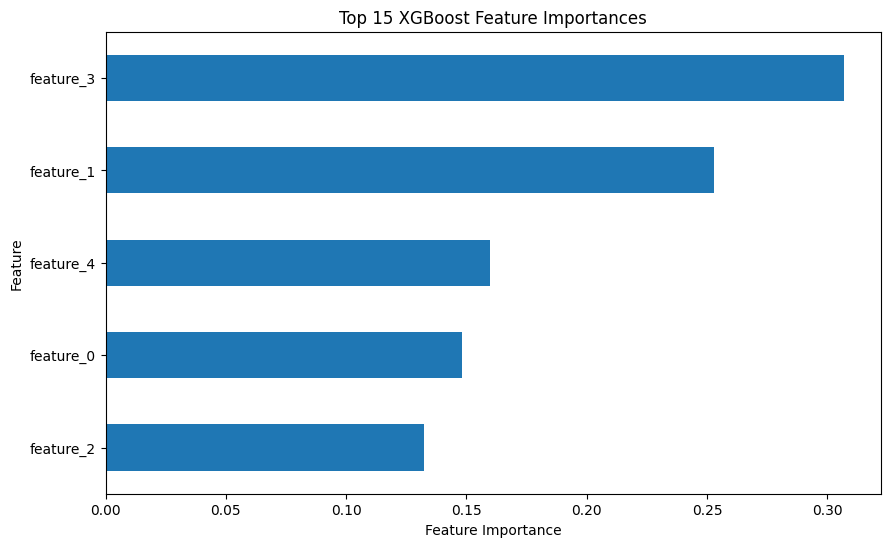

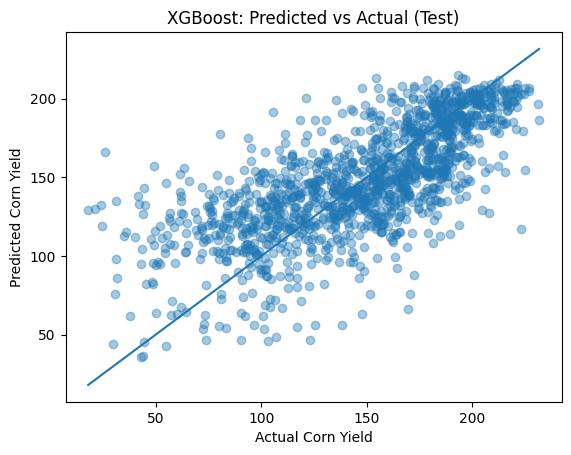

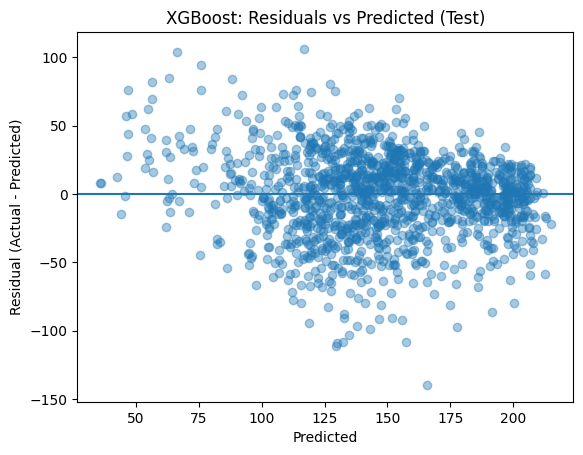

In [35]:
# XGBoost regressor comparison cell (fixed feature names)
from xgboost import XGBRegressor

np.random.seed(SEED)

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    min_child_weight=3,
    objective="reg:squarederror",
    random_state=SEED
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Predictions
val_pred_xgb = xgb_model.predict(X_val)
test_pred_xgb = xgb_model.predict(X_test)

# Metrics
xgb_rows = [
    regression_metrics(y_val, val_pred_xgb, "XGBoost (Val)"),
    regression_metrics(y_test, test_pred_xgb, "XGBoost (Test)")
]

xgb_results_df = pd.DataFrame(xgb_rows)
display(xgb_results_df)

# Append to overall results table if it already exists
try:
    results_df = pd.concat([results_df, xgb_results_df], ignore_index=True)
    results_df = results_df.sort_values(by="r2", ascending=False).reset_index(drop=True)
    display(results_df)
except NameError:
    pass

# Feature names fallback
if hasattr(X_train, "columns"):
    feature_names = list(X_train.columns)
elif "feature_cols" in globals():
    feature_names = list(feature_cols)
else:
    feature_names = [f"feature_{i}" for i in range(X_train.shape[1])]

# Feature importance plot
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
xgb_importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.show()

# Predicted vs actual on test
plt.figure()
plt.scatter(y_test, test_pred_xgb, alpha=0.4)
minv = min(y_test.min(), test_pred_xgb.min())
maxv = max(y_test.max(), test_pred_xgb.max())
plt.plot([minv, maxv], [minv, maxv])
plt.xlabel("Actual Corn Yield")
plt.ylabel("Predicted Corn Yield")
plt.title("XGBoost: Predicted vs Actual (Test)")
plt.show()

# Residual plot on test
xgb_residuals = y_test.values - test_pred_xgb
plt.figure()
plt.scatter(test_pred_xgb, xgb_residuals, alpha=0.4)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("XGBoost: Residuals vs Predicted (Test)")
plt.show()